# Phase 2A — Random Forest Baseline (FMA Pre-computed Features)

**Input:** `FMA_Data/fma_metadata/features.csv` — 518 features คำนวณจากเพลงเต็ม 30s โดย FMA  
**Split:** ใช้ official FMA split จาก `tracks.csv` (80/10/10)  
**Output:** `output/models/rf_baseline.pkl`, `rf_results.json`, confusion matrix, feature importance

| | ก่อน (Phase 1B .pt) | ใหม่ (FMA features.csv) |
|---|---|---|
| Features | 88 (3s chunk) | **518 (30s เต็ม)** |
| Source | เราคำนวณเอง | FMA official |
| ต้อง extract ก่อน | ใช่ | **ไม่ต้อง** |

## Cell 1: Imports & Config

In [1]:
import json
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Paths (relative to baseline/)
FMA_META_DIR = Path('../FMA_Data/fma_metadata/fma_metadata')
FEATURES_CSV = FMA_META_DIR / 'features.csv'
TRACKS_CSV   = FMA_META_DIR / 'tracks.csv'
MODELS_DIR   = Path('output/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

GENRE_LABELS = [
    'Electronic', 'Experimental', 'Folk', 'Hip-Hop',
    'Instrumental', 'International', 'Pop', 'Rock',
]
GENRE_TO_IDX = {g: i for i, g in enumerate(GENRE_LABELS)}

print(f'features.csv : {FEATURES_CSV.exists()} ({FEATURES_CSV})')
print(f'tracks.csv   : {TRACKS_CSV.exists()} ({TRACKS_CSV})')
print(f'models dir   : {MODELS_DIR.resolve()}')

features.csv : True (..\FMA_Data\fma_metadata\fma_metadata\features.csv)
tracks.csv   : True (..\FMA_Data\fma_metadata\fma_metadata\tracks.csv)
models dir   : D:\patt\project\pattern-music\baseline\output\models


## Cell 2: Load FMA Features & Split

In [2]:
print('Loading features.csv (518 features, ~106k tracks)...')
t0 = time.time()

# Multi-level header: [feature_type, statistic, number]
features = pd.read_csv(FEATURES_CSV, index_col=0, header=[0, 1, 2])
print(f'  features shape : {features.shape}  ({time.time()-t0:.1f}s)')

# โหลด tracks metadata (multi-level header)
print('Loading tracks.csv...')
tracks = pd.read_csv(TRACKS_CSV, index_col=0, header=[0, 1])

# Filter เฉพาะ FMA Small
small_mask = tracks[('set', 'subset')] == 'small'
small_tracks = tracks[small_mask].copy()

# ดึง split และ genre
split_col = small_tracks[('set', 'split')]          # 'training' / 'validation' / 'test'
genre_col = small_tracks[('track', 'genre_top')]    # 'Rock', 'Hip-Hop', etc.

# ลบ track ที่ไม่มี genre หรือไม่อยู่ใน 8 genres
valid_mask = genre_col.isin(GENRE_LABELS) & genre_col.notna()
valid_ids  = small_tracks[valid_mask].index

# ตรง features กับ valid track IDs
common_ids = valid_ids.intersection(features.index)
print(f'  FMA Small tracks : {len(valid_ids):,}')
print(f'  With features    : {len(common_ids):,}')

# สร้าง dataframe
X_all = features.loc[common_ids].copy()
y_all = genre_col.loc[common_ids].map(GENRE_TO_IDX).astype(int)
split_all = split_col.loc[common_ids]

# Flatten multi-level column names → "chroma_cens_kurtosis_01"
X_all.columns = ['_'.join(col).strip() for col in X_all.columns]
FEATURE_NAMES = X_all.columns.tolist()

print(f'  Feature count    : {len(FEATURE_NAMES)}')
print(f'  Split distribution:')
print(split_all.value_counts().to_string(index=True))

Loading features.csv (518 features, ~106k tracks)...
  features shape : (106574, 518)  (14.2s)
Loading tracks.csv...
  FMA Small tracks : 8,000
  With features    : 8,000
  Feature count    : 518
  Split distribution:
(set, split)
training      6400
validation     800
test           800


## Cell 3: Train/Val/Test Split + Scale

In [3]:
# แบ่งตาม official FMA split
train_mask = split_all == 'training'
val_mask   = split_all == 'validation'
test_mask  = split_all == 'test'

X_train_raw = X_all[train_mask].values.astype(np.float32)
X_val_raw   = X_all[val_mask].values.astype(np.float32)
X_test_raw  = X_all[test_mask].values.astype(np.float32)
y_train = y_all[train_mask].values
y_val   = y_all[val_mask].values
y_test  = y_all[test_mask].values

# StandardScaler — fit on training only
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

# ลบ NaN ที่อาจเกิดจาก features บางตัว (เช่น track สั้นมาก)
def remove_nan_cols(Xtr, Xv, Xt):
    nan_cols = np.isnan(Xtr).any(axis=0)
    if nan_cols.any():
        print(f'  Dropping {nan_cols.sum()} NaN columns')
    return Xtr[:, ~nan_cols], Xv[:, ~nan_cols], Xt[:, ~nan_cols]

X_train, X_val, X_test = remove_nan_cols(X_train, X_val, X_test)

print(f'X_train : {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val   : {X_val.shape}   y_val:   {y_val.shape}')
print(f'X_test  : {X_test.shape}  y_test:  {y_test.shape}')
print(f'\nClass distribution (training):')
for i, g in enumerate(GENRE_LABELS):
    print(f'  {g:<15} {(y_train == i).sum():,}')

X_train : (6400, 518)  y_train: (6400,)
X_val   : (800, 518)   y_val:   (800,)
X_test  : (800, 518)  y_test:  (800,)

Class distribution (training):
  Electronic      800
  Experimental    800
  Folk            800
  Hip-Hop         800
  Instrumental    800
  International   800
  Pop             800
  Rock            800


## Cell 4: Train Random Forest

In [4]:
rf = RandomForestClassifier(
    n_estimators     = 500,
    max_depth        = None,
    min_samples_leaf = 2,
    n_jobs           = -1,
    random_state     = 42,
    class_weight     = 'balanced',
)

print('Training RandomForestClassifier (n_estimators=500)...')
t0 = time.time()
rf.fit(X_train, y_train)
train_time = time.time() - t0
print(f'Done in {train_time:.1f}s')

Training RandomForestClassifier (n_estimators=500)...
Done in 5.2s


## Cell 5: Validation Evaluation

In [5]:
y_val_pred = rf.predict(X_val)
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print(f'Validation weighted F1: {val_f1:.4f}')
print()
print(classification_report(y_val, y_val_pred, target_names=GENRE_LABELS, digits=3))

Validation weighted F1: 0.5402

               precision    recall  f1-score   support

   Electronic      0.552     0.640     0.593       100
 Experimental      0.551     0.540     0.545       100
         Folk      0.633     0.810     0.711       100
      Hip-Hop      0.613     0.650     0.631       100
 Instrumental      0.439     0.430     0.434       100
International      0.659     0.540     0.593       100
          Pop      0.167     0.090     0.117       100
         Rock      0.644     0.760     0.697       100

     accuracy                          0.557       800
    macro avg      0.532     0.557     0.540       800
 weighted avg      0.532     0.557     0.540       800



## Cell 6: Confusion Matrix (Validation)

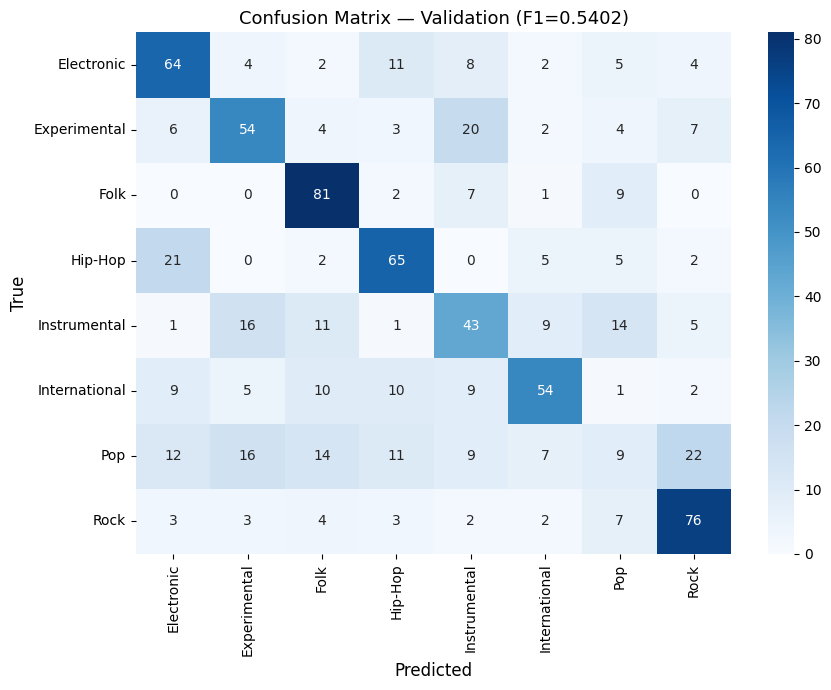

In [6]:
cm_val = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_val, annot=True, fmt='d', cmap='Blues',
    xticklabels=GENRE_LABELS, yticklabels=GENRE_LABELS, ax=ax,
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Confusion Matrix — Validation (F1={val_f1:.4f})', fontsize=13)
plt.tight_layout()
fig.savefig(MODELS_DIR / 'rf_confusion_val.png', dpi=150)
plt.show()

## Cell 7: Test Evaluation (รันครั้งเดียว — Final!)

Test weighted F1: 0.4785

               precision    recall  f1-score   support

   Electronic      0.525     0.630     0.573       100
 Experimental      0.312     0.290     0.301       100
         Folk      0.269     0.290     0.279       100
      Hip-Hop      0.625     0.650     0.637       100
 Instrumental      0.460     0.460     0.460       100
International      0.516     0.480     0.497       100
          Pop      0.481     0.370     0.418       100
         Rock      0.648     0.680     0.663       100

     accuracy                          0.481       800
    macro avg      0.479     0.481     0.479       800
 weighted avg      0.479     0.481     0.479       800



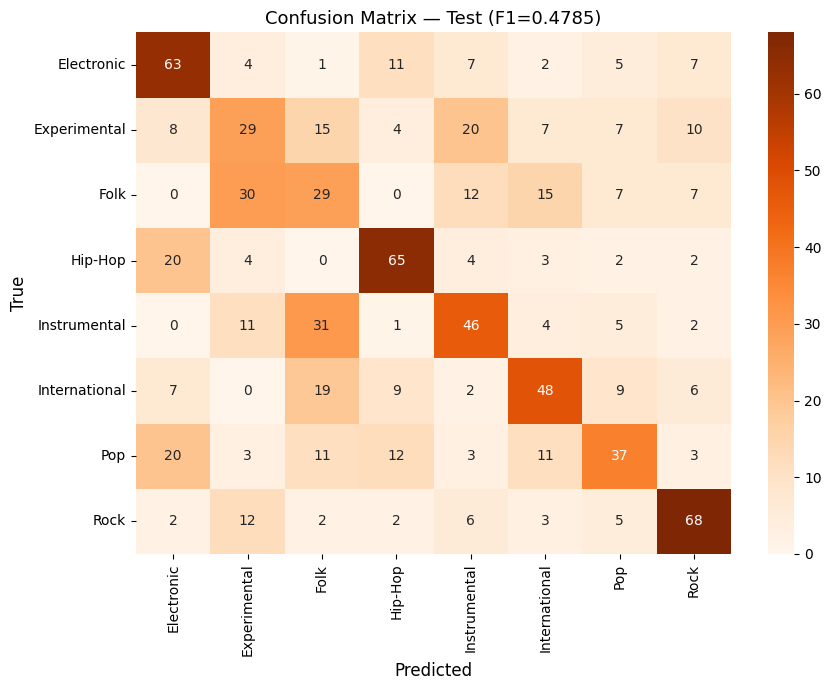

In [7]:
# ⚠️ รัน cell นี้ครั้งเดียวเท่านั้น
y_test_pred = rf.predict(X_test)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f'Test weighted F1: {test_f1:.4f}')
print()
print(classification_report(y_test, y_test_pred, target_names=GENRE_LABELS, digits=3))

cm_test = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_test, annot=True, fmt='d', cmap='Oranges',
    xticklabels=GENRE_LABELS, yticklabels=GENRE_LABELS, ax=ax,
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Confusion Matrix — Test (F1={test_f1:.4f})', fontsize=13)
plt.tight_layout()
fig.savefig(MODELS_DIR / 'rf_confusion_test.png', dpi=150)
plt.show()

## Cell 8: Latency Benchmark

In [8]:
sample   = X_test[:1]
N_TRIALS = 1000

for _ in range(10):   # warm-up
    rf.predict(sample)

times = []
for _ in range(N_TRIALS):
    t0 = time.perf_counter()
    rf.predict(sample)
    times.append(time.perf_counter() - t0)

latency_ms  = float(np.mean(times) * 1000)
latency_p95 = float(np.percentile(times, 95) * 1000)
rtf = latency_ms / 3000.0

print(f'Single-sample latency ({N_TRIALS} trials):')
print(f'  Mean : {latency_ms:.3f} ms')
print(f'  P95  : {latency_p95:.3f} ms')
print(f'  RTF  : {rtf:.6f}  ({"OK" if rtf < 1.0 else "FAIL"} — target < 1.0)')

Single-sample latency (1000 trials):
  Mean : 109.171 ms
  P95  : 146.714 ms
  RTF  : 0.036390  (OK — target < 1.0)


## Cell 9: Feature Importance (Top 20)

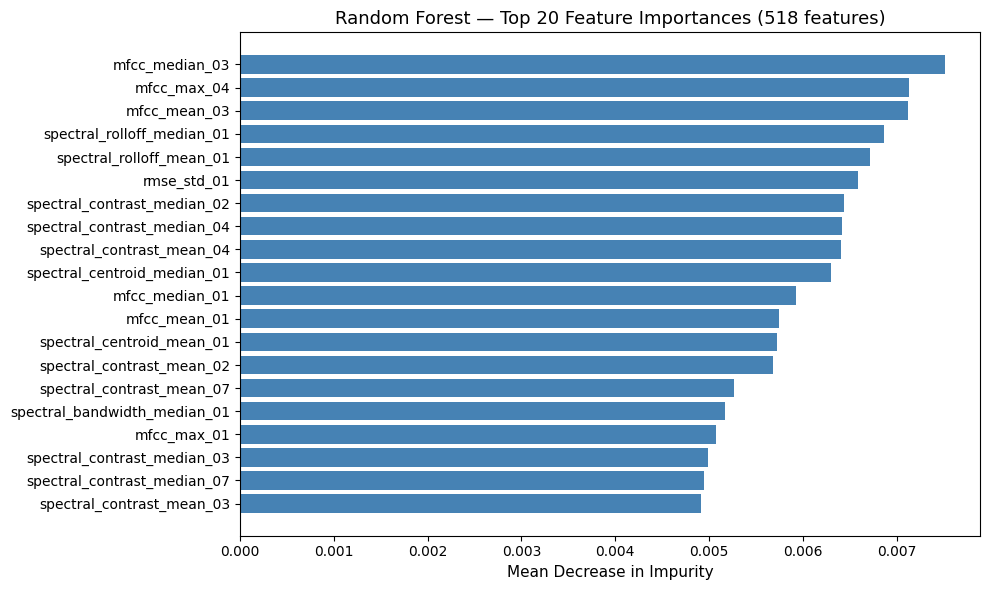

Top 20 features:
  mfcc_median_03                      0.0075  #########################
  mfcc_max_04                         0.0071  #######################
  mfcc_mean_03                        0.0071  #######################
  spectral_rolloff_median_01          0.0069  ######################
  spectral_rolloff_mean_01            0.0067  ######################
  rmse_std_01                         0.0066  #####################
  spectral_contrast_median_02         0.0064  #####################
  spectral_contrast_median_04         0.0064  #####################
  spectral_contrast_mean_04           0.0064  #####################
  spectral_centroid_median_01         0.0063  ####################
  mfcc_median_01                      0.0059  ###################
  mfcc_mean_01                        0.0057  ###################
  spectral_centroid_mean_01           0.0057  ###################
  spectral_contrast_mean_02           0.0057  ##################
  spectral_contrast_mean_07    

In [9]:
TOP_N = 20
importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1][:TOP_N]
top_names   = [FEATURE_NAMES[i] for i in indices]
top_vals    = importances[indices]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(TOP_N), top_vals[::-1], align='center', color='steelblue')
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_names[::-1])
ax.set_xlabel('Mean Decrease in Impurity', fontsize=11)
ax.set_title(f'Random Forest — Top {TOP_N} Feature Importances (518 features)', fontsize=13)
plt.tight_layout()
fig.savefig(MODELS_DIR / 'rf_feature_importance.png', dpi=150)
plt.show()

print(f'Top {TOP_N} features:')
for name, val in zip(top_names, top_vals):
    bar = '#' * int(val / top_vals[0] * 25)
    print(f'  {name:<35} {val:.4f}  {bar}')

## Cell 10: Save Model & Summary

In [10]:
# Save model
model_path = MODELS_DIR / 'rf_baseline.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({'model': rf, 'scaler': scaler, 'feature_names': FEATURE_NAMES}, f)
print(f'Saved model: {model_path}  ({model_path.stat().st_size / 1e6:.1f} MB)')

# Save results
results = {
    'val_f1_weighted':  float(val_f1),
    'test_f1_weighted': float(test_f1),
    'per_class_f1': dict(zip(
        GENRE_LABELS,
        f1_score(y_test, y_test_pred, average=None).tolist(),
    )),
    'latency_ms':      latency_ms,
    'latency_p95_ms':  latency_p95,
    'rtf':             rtf,
    'n_features':      X_train.shape[1],
    'n_estimators':    rf.n_estimators,
    'n_train_samples': int(X_train.shape[0]),
    'train_time_s':    round(train_time, 1),
    'feature_source':  'FMA features.csv (30s full track)',
}
results_path = MODELS_DIR / 'rf_results.json'
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f'Saved results: {results_path}')

# Summary
print()
print('=' * 60)
print('  PHASE 2A COMPLETE — Random Forest Baseline')
print('=' * 60)
print(f'  Feature source   : FMA features.csv (30s, 518 features)')
print(f'  Val  weighted F1 : {val_f1:.4f}')
print(f'  Test weighted F1 : {test_f1:.4f}')
print(f'  Latency (mean)   : {latency_ms:.3f} ms')
print(f'  RTF              : {rtf:.6f}  (< 1.0 = real-time capable)')
print(f'  Training time    : {train_time:.1f}s')
print()
print('  Per-class F1 on test:')
for genre, score in zip(GENRE_LABELS, f1_score(y_test, y_test_pred, average=None)):
    bar = '#' * int(score * 30)
    print(f'    {genre:<15} {score:.3f}  {bar}')
print()
print('  Next: Phase 2B — 2D CNN (mel spectrogram)')

Saved model: output\models\rf_baseline.pkl  (136.2 MB)
Saved results: output\models\rf_results.json

  PHASE 2A COMPLETE — Random Forest Baseline
  Feature source   : FMA features.csv (30s, 518 features)
  Val  weighted F1 : 0.5402
  Test weighted F1 : 0.4785
  Latency (mean)   : 109.171 ms
  RTF              : 0.036390  (< 1.0 = real-time capable)
  Training time    : 5.2s

  Per-class F1 on test:
    Electronic      0.573  #################
    Experimental    0.301  #########
    Folk            0.279  ########
    Hip-Hop         0.637  ###################
    Instrumental    0.460  #############
    International   0.497  ##############
    Pop             0.418  ############
    Rock            0.663  ###################

  Next: Phase 2B — 2D CNN (mel spectrogram)
